# Tag KNN Validation
Loads `tag_embeddings.json` and validates with KNN.

> **Before running**: Make sure `tag_embeddings.json` exists in `data/embeddings/`.

In [9]:
import json
import os
import umap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

## Config

In [10]:
EMBEDDINGS_PATH  = '../data/embeddings/tag_embeddings.json'
PLOT_PATH = "../outputs/plots/tags/"
K = 10
N_CLUSTERS = 20
MIN_CLUSTER_SIZE = 8

QUERY_TAGS = ["melancholic", "energetic", "aggressive", "chill", "romantic",
              "danceable", "dark", "happy", "sad", "atmospheric"]
SPOT_TAGS  = ["melancholic", "happy", "aggressive", "chill", "romantic", "dark"]

## 1. Load Embeddings

In [11]:
os.makedirs(PLOT_PATH, exist_ok=True)

with open(EMBEDDINGS_PATH) as f:
    raw = json.load(f)

tags      = list(raw.keys())
token2idx = {t: i for i, t in enumerate(tags)}
X         = np.array(list(raw.values()), dtype=np.float32)

print(f"{len(tags)} tags | dim={X.shape[1]}")

985 tags | dim=64


## 2. KNN

In [12]:
nbrs = NearestNeighbors(n_neighbors=K+1, metric='cosine').fit(X)
distances, indices = nbrs.kneighbors(X)

def knn(query, k=5):
    if query not in token2idx:
        return f"'{query}' not in vocab"
    idx = token2idx[query]
    return [(tags[indices[idx][i]], 1 - distances[idx][i]) for i in range(1, k+1)]

for q in SPOT_TAGS:
    if q not in token2idx: continue
    print(f"\n→ {q}")
    for name, sim in knn(q):
        print(f"   {name:<30} {sim:.3f}")


→ melancholic
   haunting                       0.638
   pretty                         0.619
   relaxed                        0.616
   relax                          0.611
   songwriter                     0.594

→ happy
   feelgood                       0.672
   fast                           0.629
   fiesta                         0.610
   poprock                        0.599
   cute                           0.586

→ aggressive
   hate                           0.725
   thrash                         0.656
   aggro                          0.639
   insane                         0.594
   war                            0.584

→ chill
   chillout                       0.629
   peace                          0.614
   slow                           0.576
   poignant                       0.549
   pleasant                       0.538

→ romantic
   lovesong                       0.688
   melancholy                     0.653
   oldies                         0.632
   sunday            

## 3. UMAP

C:\Users\Nick\Documents\Musical-Blob\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


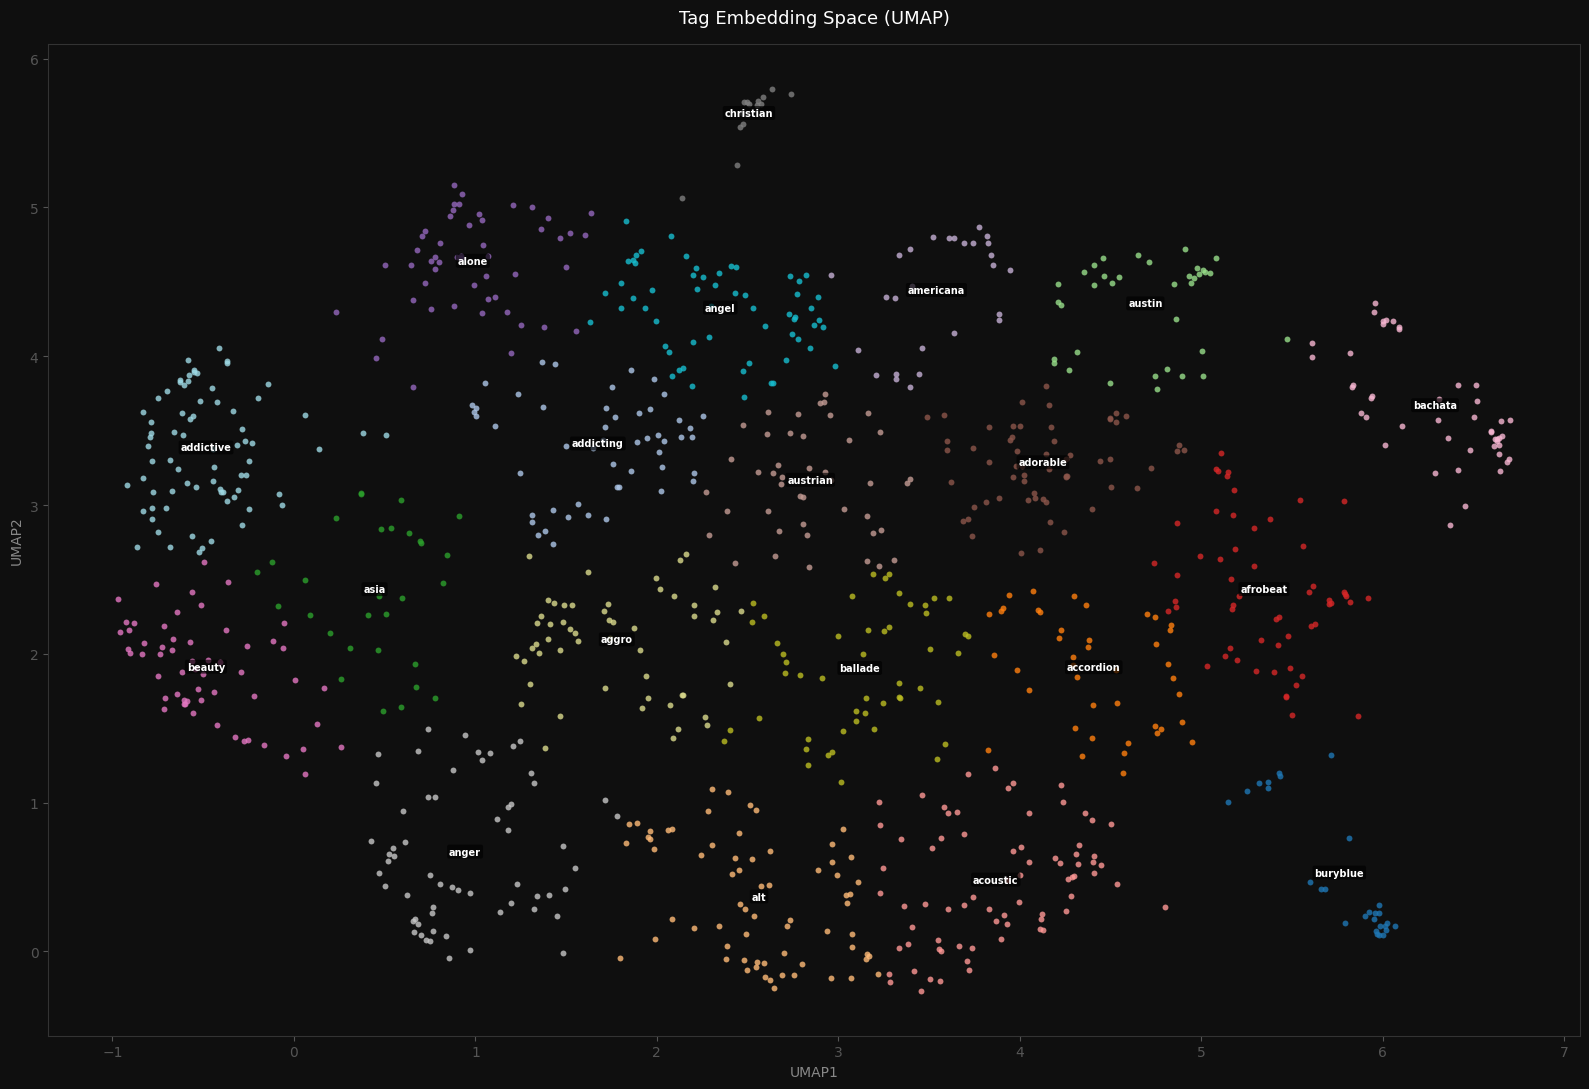

In [13]:
reducer     = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb2d       = reducer.fit_transform(X)

km          = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_ids = km.fit_predict(emb2d)

def is_clean(name):
    if len(name) > 20: return False
    if not name.replace('-', '').replace(' ', '').isalpha(): return False
    if any(c.isupper() for c in name): return False
    return True

cluster_labels = {}
for ci in range(N_CLUSTERS):
    mask = np.where(cluster_ids == ci)[0]
    if len(mask) < MIN_CLUSTER_SIZE: continue
    names = [tags[i] for i in mask if is_clean(tags[i])]
    if names:
        cluster_labels[ci] = Counter(names).most_common(1)[0][0]

cmap_clusters = matplotlib.colormaps['tab20'].resampled(N_CLUSTERS)

fig, ax = plt.subplots(figsize=(16, 11), facecolor='#0f0f0f')
ax.set_facecolor('#0f0f0f')
for ci in range(N_CLUSTERS):
    mask = np.where(cluster_ids == ci)[0]
    if len(mask) == 0: continue
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1], c=[cmap_clusters(ci)], s=18, alpha=0.8, linewidths=0)
    if len(mask) >= MIN_CLUSTER_SIZE and ci in cluster_labels:
        cx, cy = emb2d[mask, 0].mean(), emb2d[mask, 1].mean()
        ax.annotate(cluster_labels[ci], (cx, cy), color='white', fontsize=7,
                    ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#000000aa', edgecolor='none'))
ax.set_title('Tag Embedding Space (UMAP)', color='white', fontsize=13, pad=15)
ax.set_xlabel('UMAP1', color='#888888'); ax.set_ylabel('UMAP2', color='#888888')
ax.tick_params(colors='#555555')
for spine in ax.spines.values(): spine.set_color('#333333')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, "tag_embedding_space.png"))
plt.show()

## 4. Cosine Similarity Heatmap

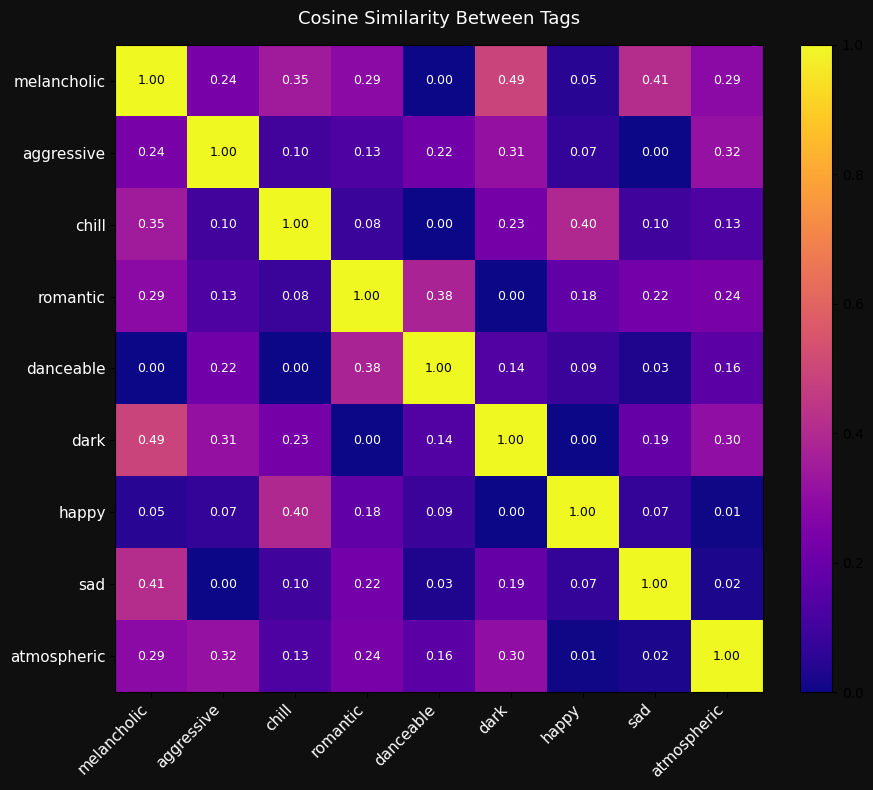

In [14]:
q_tags = [q for q in QUERY_TAGS if q in token2idx]
n = len(q_tags)
sim_matrix = np.zeros((n, n))
for i, ta in enumerate(q_tags):
    va = X[token2idx[ta]]
    for j, tb in enumerate(q_tags):
        vb = X[token2idx[tb]]
        sim_matrix[i,j] = max(0, (np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb)+1e-9)))

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0f0f0f')
ax.set_facecolor('#0f0f0f')
im = ax.imshow(sim_matrix, cmap='plasma', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(q_tags, rotation=45, ha='right', color='white', fontsize=11)
ax.set_yticks(range(n)); ax.set_yticklabels(q_tags, color='white', fontsize=11)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                color='white' if sim_matrix[i,j] < 0.7 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Cosine Similarity Between Tags', color='white', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, "tag_cosine_similarity.png"))
plt.show()

## 5. KNN Bar Charts

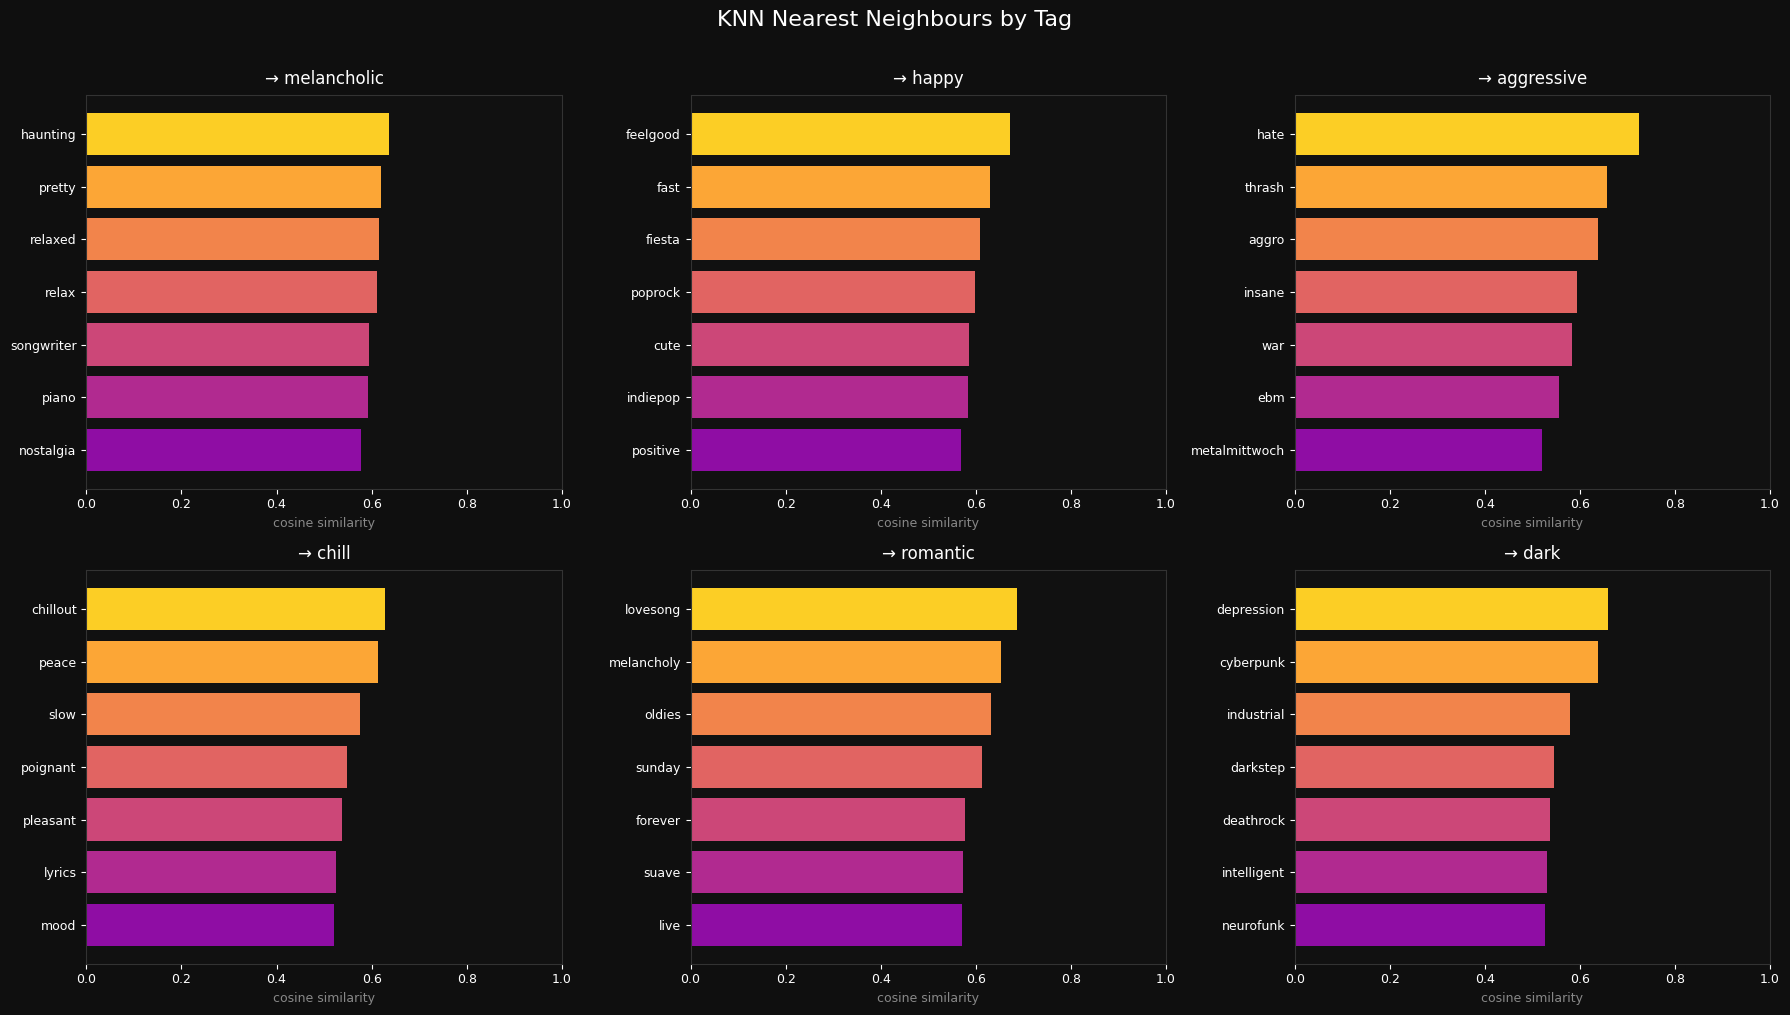

In [15]:
def is_clean(name):
    if len(name) > 40: return False
    if any(c.isdigit() for c in name): return False
    return True

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#0f0f0f')
axes = axes.flatten()

for ax, q in zip(axes, SPOT_TAGS):
    ax.set_facecolor('#111111')
    if q not in token2idx:
        ax.set_visible(False); continue
    idx = token2idx[q]
    neighbours = []
    for i in range(1, len(indices[idx])):
        name = tags[indices[idx][i]]
        if is_clean(name):
            neighbours.append((name, 1 - distances[idx][i]))
        if len(neighbours) == 7: break
    names = [n for n, _ in neighbours]
    sims  = [s for _, s in neighbours]
    ax.barh(names[::-1], sims[::-1], color=plt.cm.plasma(np.linspace(0.3, 0.9, len(names))))
    ax.set_xlim(0, 1)
    ax.set_title(f'→ {q}', color='white', fontsize=12, pad=8)
    ax.tick_params(colors='white', labelsize=9)
    ax.set_xlabel('cosine similarity', color='#888888', fontsize=9)
    for spine in ax.spines.values(): spine.set_color('#333333')

plt.suptitle('KNN Nearest Neighbours by Tag', color='white', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_PATH, "tag_nearest_neighbors.png"))
plt.show()

## 6. Metrics

In [16]:
norms = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = X / (norms + 1e-9)

sim_matrix = X_norm @ X_norm.T
mask = np.triu(np.ones(len(tags), dtype=bool), k=1)
mean_sim = sim_matrix[mask].mean()

eigvals = np.linalg.eigvalsh(X_norm.T @ X_norm)
eigvals = eigvals[eigvals > 0]
isotropy = np.exp(-(eigvals / eigvals.sum() * np.log(eigvals / eigvals.sum() + 1e-9)).sum()) / len(eigvals)

print(f"Mean pairwise similarity: {mean_sim:.3f}  (lower = more spread)")
print(f"Isotropy:                 {isotropy:.3f}  (higher = better use of space)")

Mean pairwise similarity: 0.175  (lower = more spread)
Isotropy:                 0.683  (higher = better use of space)
